In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
pd.options.display.max_columns= None

In [2]:
path= 'loan_data_2007_2014.csv'
data= pd.read_csv(path, index_col= 0)
df= data.copy()

C:\Users\mmopa\AppData\Local\Temp\ipykernel_14544\4170862570.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(path, index_col= 0)


In [3]:
df.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(466285, 74)

In [5]:
pd.set_option('display.max_rows', None)

In [6]:
import io
from IPython.display import display, HTML

buffer = io.StringIO()
df.info(verbose=True, show_counts=True, buf=buffer)
info_str = buffer.getvalue()

# Added 'color: black' to ensure text is visible on the light background
display(HTML(f"""
    <div style="height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px; background-color: #ffffff; color: black;">
        <pre style="color: black; font-family: monospace;">{info_str}</pre>
    </div>
"""))

In [7]:
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [8]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [9]:
df['status']= df['loan_status'].apply(lambda x: 1 if x in ['Charged Off','Default','Late (31-120 days)','Does not meet the credit policy. Status:Charged Off'] else 0)

**WOE/IV**

In [10]:
from category_encoders import WOEEncoder


In [11]:
encoder = WOEEncoder(cols=['grade'])
X_encoded = encoder.fit_transform(df.drop('status', axis= 1), df['status'])

In [12]:
X_encoded['grade_o']= df['grade']

In [13]:
c= X_encoded.groupby('grade_o')['grade'].mean()
c

grade_o
A   -1.114433
B   -0.363993
C    0.055277
D    0.395035
E    0.678540
F    0.952393
G    1.144796
Name: grade, dtype: float64

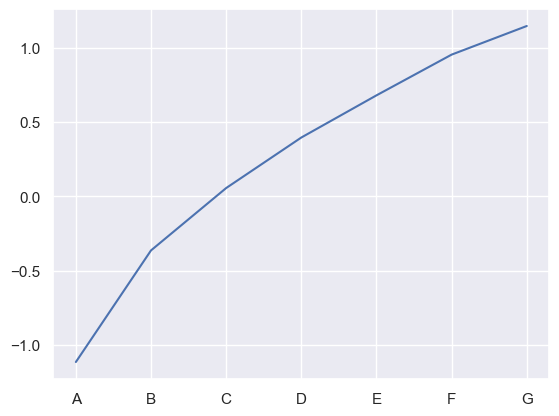

In [14]:
plt.figure()
plt.plot(c)
plt.show()

In [15]:
X_encoded.groupby('grade_o')[['grade_o','grade']].count()

,grade_o,grade
grade_o,,
A,74867,74867
B,136929,136929
C,125293,125293
D,76888,76888
E,35757,35757
F,13229,13229
G,3322,3322


In [17]:
df['status'].value_counts(normalize= True)

status
0    0.890693
1    0.109307
Name: proportion, dtype: float64